In [1]:
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching as pm

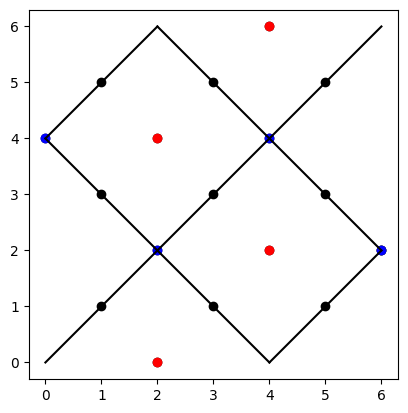

In [2]:
qubit_x = [1, 2, 3, 5, 1, 2, 3, 4, 5, 6, 0, 1, 2, 3, 4, 5, 4, 6]
qubit_y = [1, 0, 1, 1, 3, 2, 3, 2, 3, 2, 4, 5, 4, 5, 4, 5, 6, 2]
xancilla_x = [0, 2, 4, 6]
xancilla_y = [4, 2, 4, 2]
zancilla_x = [2, 4, 2, 4]
zancilla_y = [0, 2, 4, 6]

plt.plot(qubit_x, qubit_y, 'o', color='black')
plt.plot(xancilla_x, xancilla_y, 'o', color='blue')
plt.plot(zancilla_x, zancilla_y, 'o', color='red')
# Draw the line connecting (0,0) and (6,6)
plt.plot([0, 6], [0, 6], color='black')
plt.plot([0, 4], [4, 0], color='black')
plt.plot([2, 6], [6, 2], color='black')
plt.plot([0, 2], [4, 6], color='black')
plt.plot([4, 6], [0, 2], color='black')

plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [15]:
p = 0.002
circuit_initial = stim.Circuit.generated("surface_code:rotated_memory_x", 
                                        distance=3, 
                                        rounds=100, 
                                        after_clifford_depolarization=p,
                                        before_round_data_depolarization=p,
                                        after_reset_flip_probability=p,
                                        before_measure_flip_probability=p)

In [16]:
ds = circuit_initial.compile_detector_sampler()
D, L = ds.sample(1000000, separate_observables=True)
model = circuit_initial.detector_error_model(decompose_errors=True)
matching = pm.Matching.from_detector_error_model(model)
pred = matching.decode_batch(D)
print(np.sum(pred[:, 0] != L[:, 0]) / 1000000)

0.095282


In [3]:
circuit_initial

stim.Circuit('''
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 0) 2
    QUBIT_COORDS(3, 1) 3
    QUBIT_COORDS(5, 1) 5
    QUBIT_COORDS(1, 3) 8
    QUBIT_COORDS(2, 2) 9
    QUBIT_COORDS(3, 3) 10
    QUBIT_COORDS(4, 2) 11
    QUBIT_COORDS(5, 3) 12
    QUBIT_COORDS(6, 2) 13
    QUBIT_COORDS(0, 4) 14
    QUBIT_COORDS(1, 5) 15
    QUBIT_COORDS(2, 4) 16
    QUBIT_COORDS(3, 5) 17
    QUBIT_COORDS(4, 4) 18
    QUBIT_COORDS(5, 5) 19
    QUBIT_COORDS(4, 6) 25
    RX 1 3 5 8 10 12 15 17 19
    Z_ERROR(0.003) 1 3 5 8 10 12 15 17 19
    R 2 9 11 13 14 16 18 25
    X_ERROR(0.003) 2 9 11 13 14 16 18 25
    TICK
    DEPOLARIZE1(0.003) 1 3 5 8 10 12 15 17 19
    H 2 11 16 25
    DEPOLARIZE1(0.003) 2 11 16 25
    TICK
    CX 2 3 16 17 11 12 15 14 10 9 19 18
    DEPOLARIZE2(0.003) 2 3 16 17 11 12 15 14 10 9 19 18
    TICK
    CX 2 1 16 15 11 10 8 14 3 9 12 18
    DEPOLARIZE2(0.003) 2 1 16 15 11 10 8 14 3 9 12 18
    TICK
    CX 16 10 11 5 25 19 8 9 17 18 12 13
    DEPOLARIZE2(0.003) 16 10 11 5 25 19 8 9 1

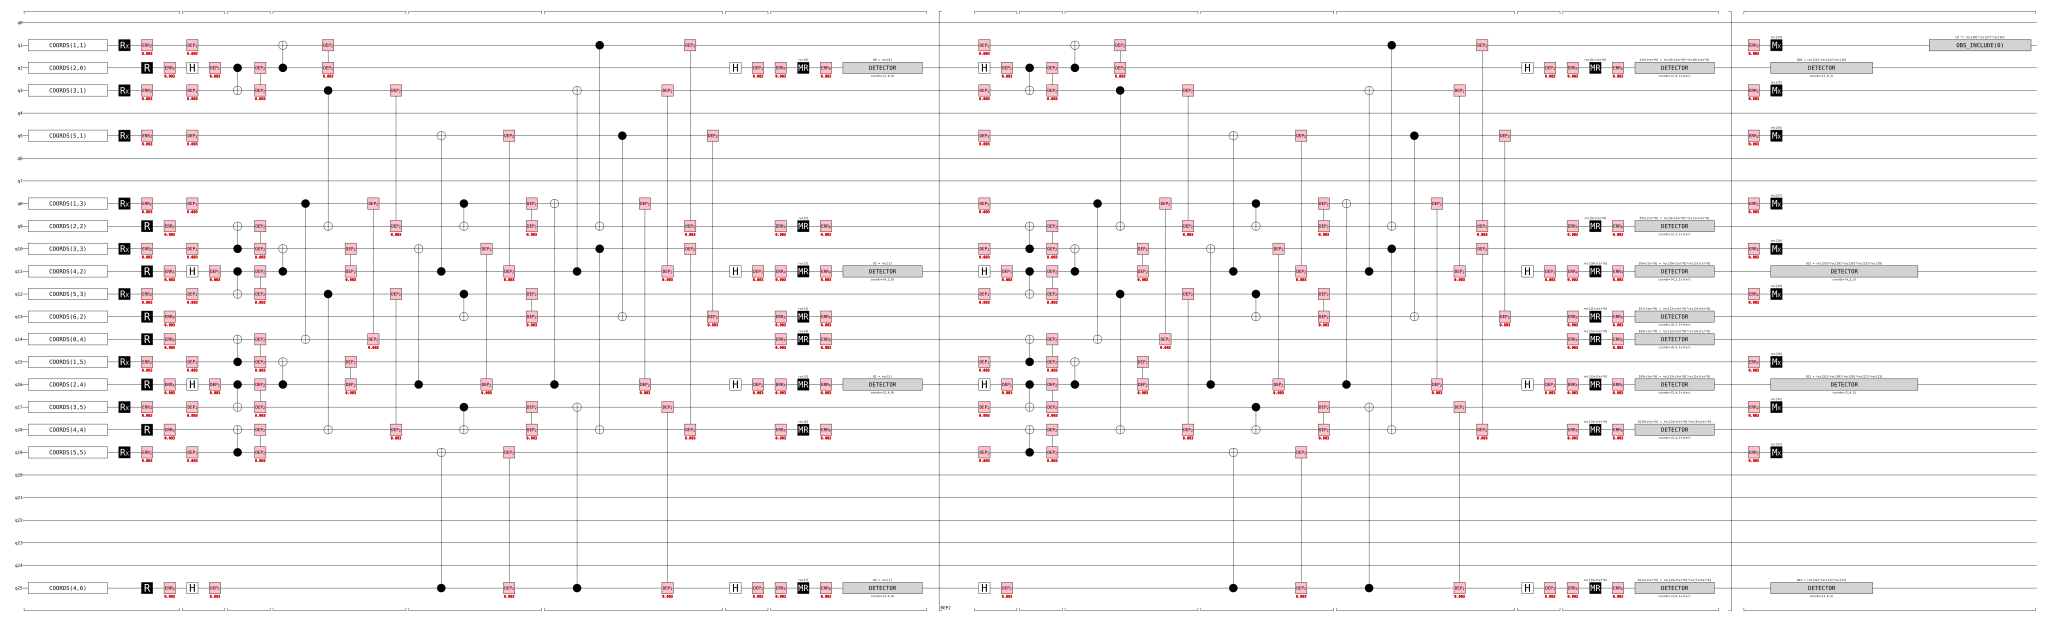

In [5]:
display(circuit_initial.diagram('timeline-svg'))
